In [ ]:
from qitf_model import *
import numpy as np

exact_model = QITFModel(hx=0.809,J=1)
analog_model = analog_QITF(exact_model,0.01)

import pickle
with open('./Figures/analog_model.pkl', 'wb') as f:
    pickle.dump(analog_model, f)

In [25]:
from qiskit.quantum_info import partial_trace
def density_matrix(state):
    return np.outer(state,state.conj())

def von_neumann_entropy(rho):
    # 计算密度矩阵的特征值
    eigenvalues = np.linalg.eigvalsh(rho)
    # 过滤掉接近零的特征值以避免数值问题
    non_zero_eigenvalues = eigenvalues[eigenvalues > 1e-10]
    entropy = -np.sum(non_zero_eigenvalues * np.log(non_zero_eigenvalues))
    return entropy

def RDM_entropy(state,k):
    entropy_list=[]
    for i in range(k):
        rho=partial_trace(Statevector(state),range(i+1,N))
        entropy_list.append(von_neumann_entropy(rho))
    return entropy_list

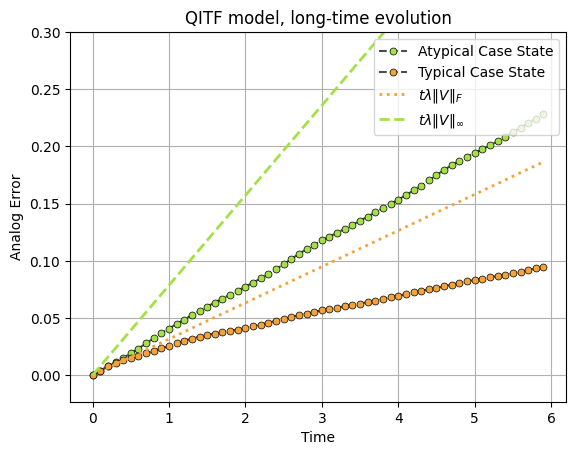

In [24]:
initial_state=Statevector.from_label('+'*N).data
    # analog_model.plot_one_segment(initial_state, mfc='#66C999', label='Separable State')
analog_model.plot_long_time(initial_state, mfc="#A4E048", label='Atypical Case State')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
analog_model.plot_long_time(initial_state, mfc='#F3A33A', label='Typical Case State')

fro_curve=[]
spec_curve=[]
V_fro = np.linalg.norm(analog_model.perm, 'fro')/sqrt(d)
V_spec = np.linalg.norm(analog_model.perm, 2)
for t in time:
    fro_curve.append(t*V_fro)
    spec_curve.append(t*V_spec)
plt.plot(time[:-1], fro_curve[:-1], color='#F3A33A', linestyle='dotted', label=r'$t\lambda\|V\|_{F}$',linewidth=2)
plt.plot(time[:-1], spec_curve[:-1], color='#A4E048', linestyle='dashed', label=r'$t\lambda\|V\|_{\infty}$',linewidth=2)
    # plt.plot(time[:-1], [V_fro*time_step]*num_steps, color='#397FC7', linestyle='dotted', label=r'$\delta t\lambda\|V\|_{F}$')
    # plt.plot(time[:-1], scrambling_value,color='0.3',marker='o',markersize=5,mfc='#66C999',mec='k',linestyle='dashed',markeredgewidth=0.5)
    # plt.plot(time[:-1], simulation_error_state,color='0.3',mfc='#5DBFE9',marker='o',markersize=5,mec='k',linestyle='dashed',markeredgewidth=0.5)
    # plt.plot(time[:-1], [average_case_commutator]*num_steps,color='#66C999',linestyle='dashed')
    # plt.plot(time[:-1], [Fro_bound]*num_steps,color='#397FC7',linestyle='dotted')
plt.xlabel('Time')
plt.ylabel('Analog Error')
plt.ylim( top=0.3)
plt.legend(loc=1)
plt.title('QITF model, long-time evolution')
plt.grid()
plt.savefig('./Figures/long-time.pdf', bbox_inches='tight',dpi=600)
plt.show()

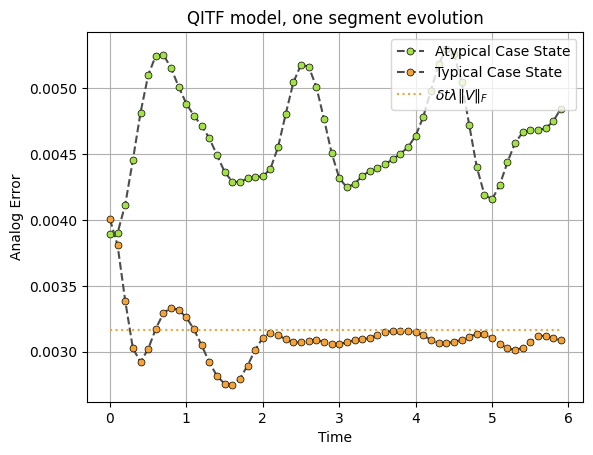

In [21]:
initial_state=Statevector.from_label('+'*N).data
analog_model.plot_one_segment(initial_state, mfc='#A4E048', label='Atypical Case State')

# initial_state = haar_random_state(N)  # Generate a random state
initial_state = Statevector.from_label('0'*N).data  # Typical case state
analog_model.plot_one_segment(initial_state, mfc='#F3A33A', label='Typical Case State')

plt.plot(time[:-1], [V_fro*time_step]*num_steps, color='#F3A33A', linestyle='dotted', label=r'$\delta t\lambda\|V\|_{F}$')
# plt.plot(time[:-1], [V_spec*time_step]*num_steps, color='#A4E048', linestyle='dashed', label=r'$\delta t\lambda\|V\|_{\infty}$')
plt.xlabel('Time')
plt.ylabel('Analog Error')
plt.title('QITF model, one segment evolution')
plt.legend(loc=1)
plt.grid()
plt.savefig('./Figures/one_segment.pdf', bbox_inches='tight',dpi=600)
plt.show()

In [12]:
import pickle
with open('./data/analog_model.pkl', 'wb') as f:
    pickle.dump(analog_model, f)